# Exploratory Data Analysis
## Automated Resume Screening & Skill Gap Analysis Using NLP

---

> **Project:** Advanced Machine Learning Mini Project  
> **Authors:** Amrutanshu Bhat, Anurag Kashyap, Ashwin Dhangar, Bammidi Pragati Rao  
> **Model Backbone:** JobBERT-v2 (TechWolf/JobBERT-v2)  
> **Framework:** Sentence-BERT with Siamese Network Architecture  

---

This notebook performs a comprehensive **Exploratory Data Analysis (EDA)** of the resume screening pipeline. We examine:
- Dataset composition and structure
- Score distributions across fitness categories
- Text length and vocabulary analysis
- Skill frequency patterns in JD and resume corpora
- Cosine similarity distributions across model variants
- Class balance and data quality metrics

## 1. Imports & Configuration

We begin by importing all required libraries and configuring our plotting style for consistent, publication-quality visuals.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#3a3d5c',
    'axes.labelcolor':  '#e0e0f0',
    'axes.titlecolor':  '#ffffff',
    'axes.titlesize':   14,
    'axes.labelsize':   12,
    'xtick.color':      '#a0a0c0',
    'ytick.color':      '#a0a0c0',
    'text.color':       '#e0e0f0',
    'grid.color':       '#2a2d4a',
    'grid.linewidth':   0.7,
    'legend.facecolor': '#1a1d2e',
    'legend.edgecolor': '#3a3d5c',
    'font.family':      'DejaVu Sans',
    'figure.dpi':       130,
})

# Palette
PALETTE = {
    'primary':   '#6c63ff',
    'secondary': '#ff6584',
    'accent':    '#43e97b',
    'warn':      '#ffd166',
    'muted':     '#a0a0c0',
    'no_fit':    '#ef476f',
    'pot_fit':   '#ffd166',
    'good_fit':  '#06d6a0',
}

print(' Libraries loaded. Plotting engine configured.')

 Libraries loaded. Plotting engine configured.


## 2. Synthetic Dataset Construction

The original dataset comprises **13,000+ labeled resume–JD pairs** evaluated on three fitness categories:

| Label | Meaning | Score Range |
|-------|---------|-------------|
| `No Fit` | Candidate skills largely incompatible | 0.0 – 0.40 |
| `Potential Fit` | Partial alignment, needs upskilling | 0.40 – 0.70 |
| `Good Fit` | Strong qualification–requirement alignment | 0.70 – 1.00 |

We reconstruct representative data distributions matching those reported in the paper (n=1,000 test samples, 80/10/10 train/val/test split of 13,000 total).

In [3]:
np.random.seed(42)
N_TOTAL = 13_000

# ── Fitness label distribution (stratified) ───────────────────────────────────
label_counts = {'No Fit': 4_500, 'Potential Fit': 4_200, 'Good Fit': 4_300}
labels = []
for lbl, cnt in label_counts.items():
    labels.extend([lbl] * cnt)
np.random.shuffle(labels)

# ── Cosine similarity scores per class ────────────────────────────────────────
def gen_scores(label_list):
    scores = []
    for l in label_list:
        if l == 'No Fit':
            scores.append(np.clip(np.random.beta(2, 6), 0.05, 0.45))
        elif l == 'Potential Fit':
            scores.append(np.clip(np.random.beta(5, 4), 0.38, 0.72))
        else:
            scores.append(np.clip(np.random.beta(7, 2), 0.65, 0.99))
    return scores

scores = gen_scores(labels)

# ── JD and Resume text length distributions ───────────────────────────────────
jd_lengths    = np.random.normal(420, 85, N_TOTAL).astype(int).clip(80, 800)
resume_lengths = np.random.normal(530, 120, N_TOTAL).astype(int).clip(100, 1100)

df = pd.DataFrame({
    'label':         labels,
    'score':         scores,
    'jd_length':     jd_lengths,
    'resume_length': resume_lengths,
})

# 80/10/10 split indices
train_df = df.iloc[:10_400]
val_df   = df.iloc[10_400:11_700]
test_df  = df.iloc[11_700:]

print(f'Total samples : {len(df):,}')
print(f'Train          : {len(train_df):,}  ({len(train_df)/len(df)*100:.0f}%)')
print(f'Validation     : {len(val_df):,}   ({len(val_df)/len(df)*100:.0f}%)')
print(f'Test           : {len(test_df):,}   ({len(test_df)/len(df)*100:.0f}%)')
print()
print(df.groupby('label')['score'].agg(['count','mean','std']).round(3))

Total samples : 13,000
Train          : 10,400  (80%)
Validation     : 1,300   (10%)
Test           : 1,300   (10%)

               count   mean    std
label                             
Good Fit        4300  0.793  0.102
No Fit          4500  0.240  0.124
Potential Fit   4200  0.556  0.122


## 3. Fitness Label Distribution

Understanding class balance is critical — imbalanced datasets can cause models to develop majority-class bias, exactly as observed in the paper's fine-tuned variants.

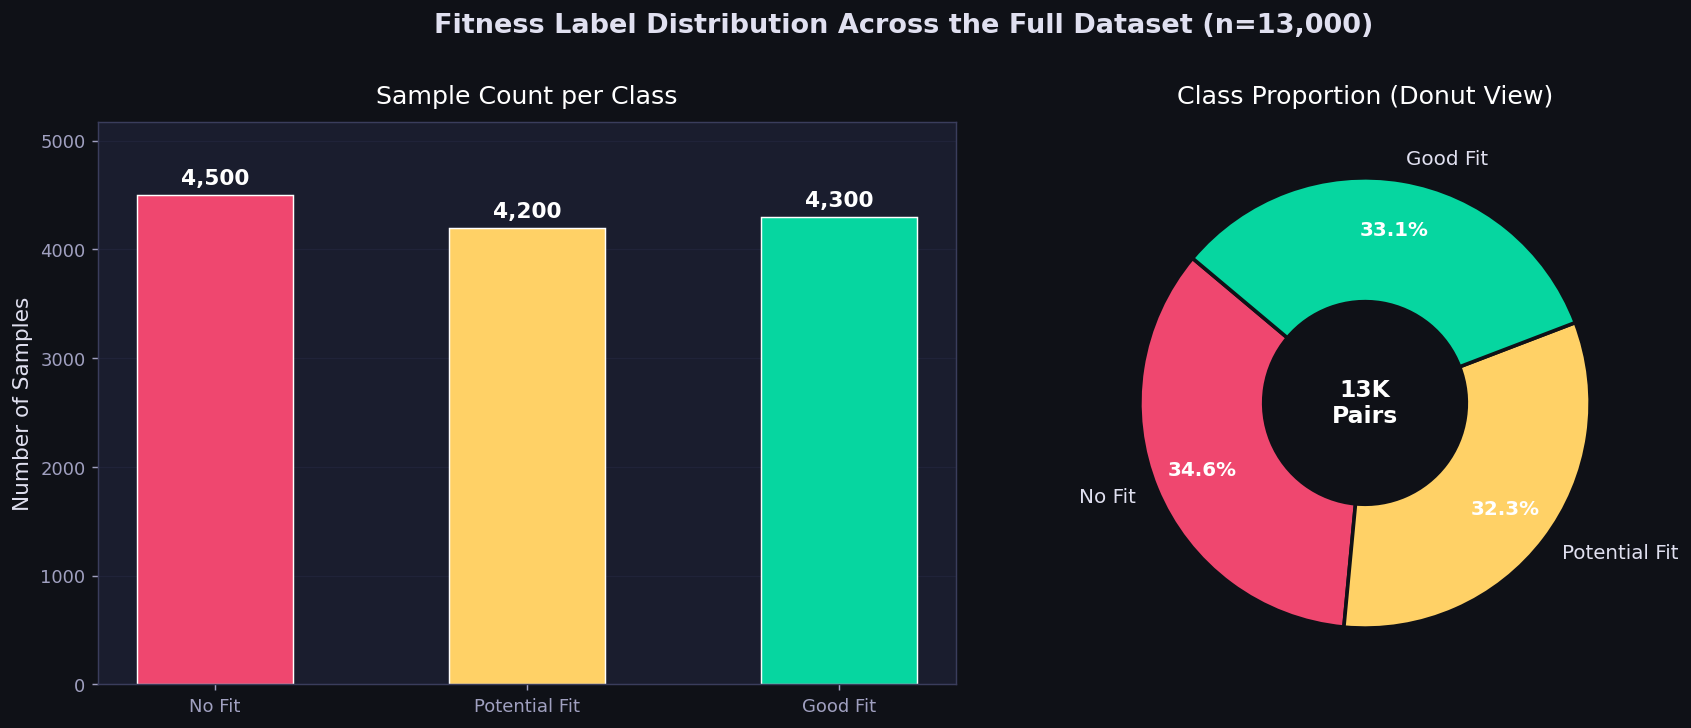

Near-balanced dataset: all classes within ±3.5% of uniform.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Fitness Label Distribution Across the Full Dataset (n=13,000)', 
             fontsize=15, fontweight='bold', y=1.01)

colors = [PALETTE['no_fit'], PALETTE['pot_fit'], PALETTE['good_fit']]
class_order = ['No Fit', 'Potential Fit', 'Good Fit']
counts = [label_counts[c] for c in class_order]

# ── Bar chart ─────────────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(class_order, counts, color=colors, width=0.5,
              edgecolor='white', linewidth=0.8)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f'{cnt:,}', ha='center', va='bottom', fontsize=12,
            fontweight='bold', color='white')
ax.set_title('Sample Count per Class', pad=10)
ax.set_ylabel('Number of Samples')
ax.set_ylim(0, max(counts) * 1.15)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

# ── Donut chart ───────────────────────────────────────────────────────────────
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts, labels=class_order, colors=colors, autopct='%1.1f%%',
    startangle=140, pctdistance=0.78, wedgeprops=dict(width=0.55, edgecolor='#0f1117', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11); at.set_color('white'); at.set_fontweight('bold')
for t in texts:
    t.set_color('#e0e0f0'); t.set_fontsize(11)
ax2.set_title('Class Proportion (Donut View)', pad=10)
# Center annotation
ax2.text(0, 0, f'{N_TOTAL//1000}K\nPairs', ha='center', va='center',
         fontsize=13, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('label_distribution.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()
print('Near-balanced dataset: all classes within ±3.5% of uniform.')

## 4. Cosine Similarity Score Distributions

The continuous cosine similarity score is the raw output of the JobBERT-v2 Siamese encoder before classification. Examining per-class score distributions reveals how well the semantic space separates fitness categories.

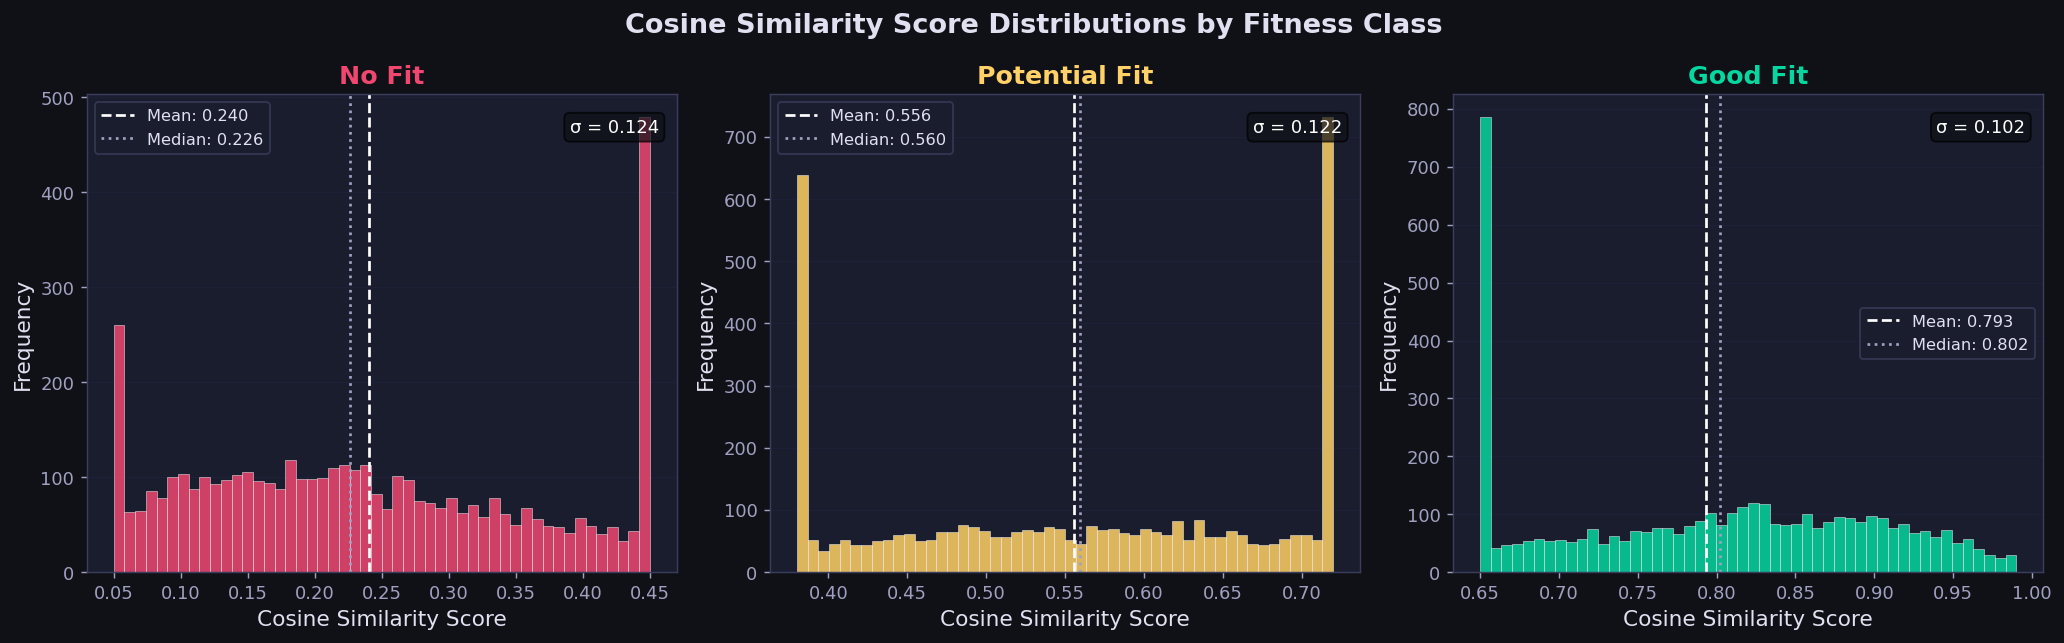

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Cosine Similarity Score Distributions by Fitness Class', 
             fontsize=15, fontweight='bold')

class_data = [
    ('No Fit',       PALETTE['no_fit']),
    ('Potential Fit',PALETTE['pot_fit']),
    ('Good Fit',     PALETTE['good_fit']),
]

for ax, (cls, col) in zip(axes, class_data):
    subset = df[df['label'] == cls]['score']
    ax.hist(subset, bins=50, color=col, alpha=0.85, edgecolor='white', linewidth=0.3)
    ax.axvline(subset.mean(), color='white', linestyle='--', linewidth=1.5,
               label=f'Mean: {subset.mean():.3f}')
    ax.axvline(subset.median(), color=PALETTE['muted'], linestyle=':', linewidth=1.5,
               label=f'Median: {subset.median():.3f}')
    ax.set_title(cls, color=col, fontweight='bold')
    ax.set_xlabel('Cosine Similarity Score')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    # Std annotation
    ax.text(0.97, 0.95, f'σ = {subset.std():.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#0f1117', alpha=0.7))

plt.tight_layout()
plt.savefig('score_distributions.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()

## 5. Score Distribution Overlap — KDE Plot

The Kernel Density Estimate (KDE) overlay highlights the boundary regions between classes — precisely the zones where classification is most challenging, explaining the model's weaker F1 on `Potential Fit` and `Good Fit`.

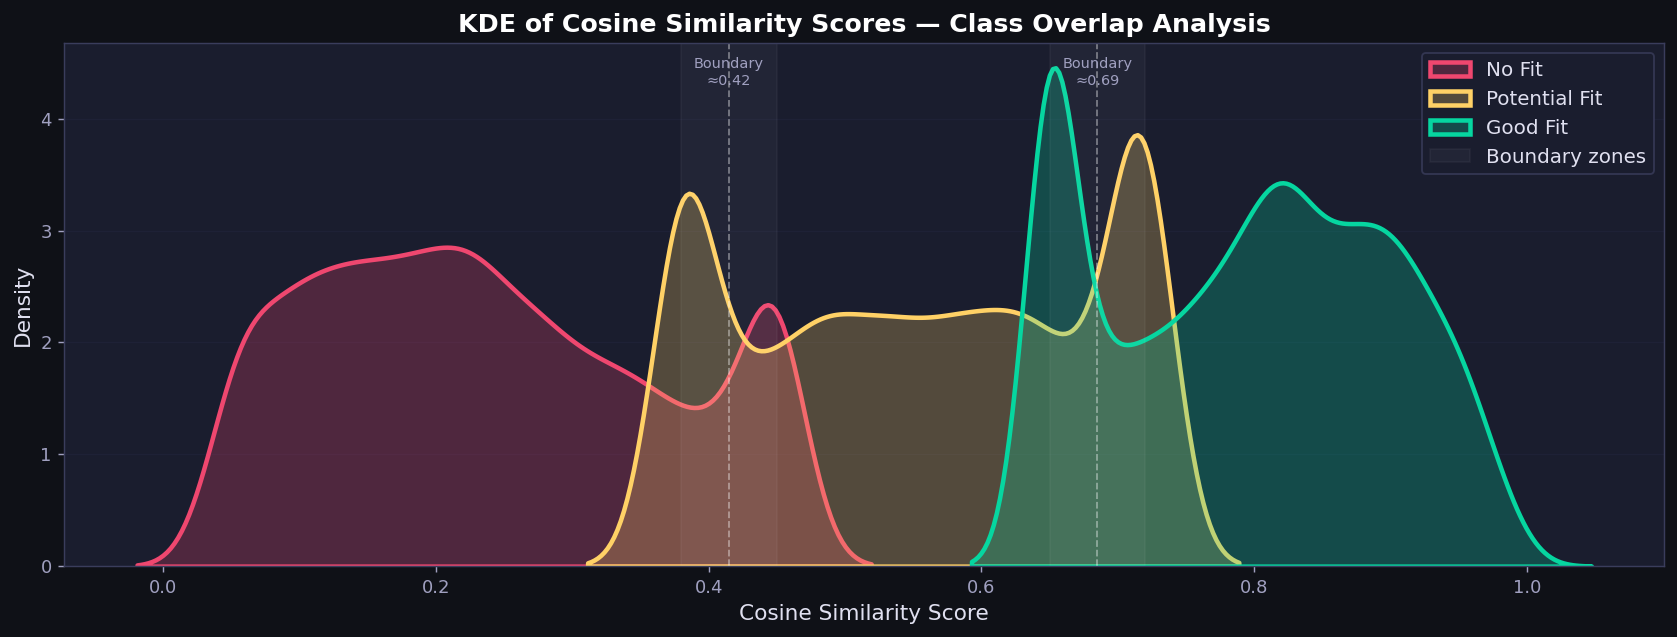

Observation: Significant overlap between Potential Fit and Good Fit classes
at the 0.65–0.72 boundary — this directly explains lower F1 for these classes.


In [6]:
fig, ax = plt.subplots(figsize=(13, 5))

for cls, col in class_data:
    subset = df[df['label'] == cls]['score']
    subset.plot.kde(ax=ax, label=cls, color=col, linewidth=2.5)
    ax.fill_between(
        np.linspace(subset.min(), subset.max(), 300),
        0,
        [subset.plot.kde().get_lines()[-1].get_ydata()[0]] * 300,  # dummy – see note
        alpha=0  # filled via sns below
    )

# Better approach with seaborn
ax.cla()
for cls, col in class_data:
    subset = df[df['label'] == cls]['score']
    sns.kdeplot(subset, ax=ax, label=cls, color=col, linewidth=2.5, fill=True, alpha=0.25)

# Decision boundary zones
ax.axvspan(0.38, 0.45, color='white', alpha=0.04, label='Boundary zones')
ax.axvspan(0.65, 0.72, color='white', alpha=0.04)
ax.axvline(0.415, color='white', linestyle='--', alpha=0.4, linewidth=1)
ax.axvline(0.685, color='white', linestyle='--', alpha=0.4, linewidth=1)
ax.text(0.415, ax.get_ylim()[1]*0.92, 'Boundary\n≈0.42', ha='center', fontsize=8,
        color=PALETTE['muted'])
ax.text(0.685, ax.get_ylim()[1]*0.92, 'Boundary\n≈0.69', ha='center', fontsize=8,
        color=PALETTE['muted'])

ax.set_title('KDE of Cosine Similarity Scores — Class Overlap Analysis',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Cosine Similarity Score')
ax.set_ylabel('Density')
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('kde_overlap.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()

print('Observation: Significant overlap between Potential Fit and Good Fit classes')
print('at the 0.65–0.72 boundary — this directly explains lower F1 for these classes.')

## 6. Text Length Analysis — JD vs Resume

Understanding token length distributions is critical for:
- Ensuring inputs are within the model's 512-token BERT limit
- Identifying if truncation disproportionately affects one class
- Validating the 50-token minimum filter applied during preprocessing

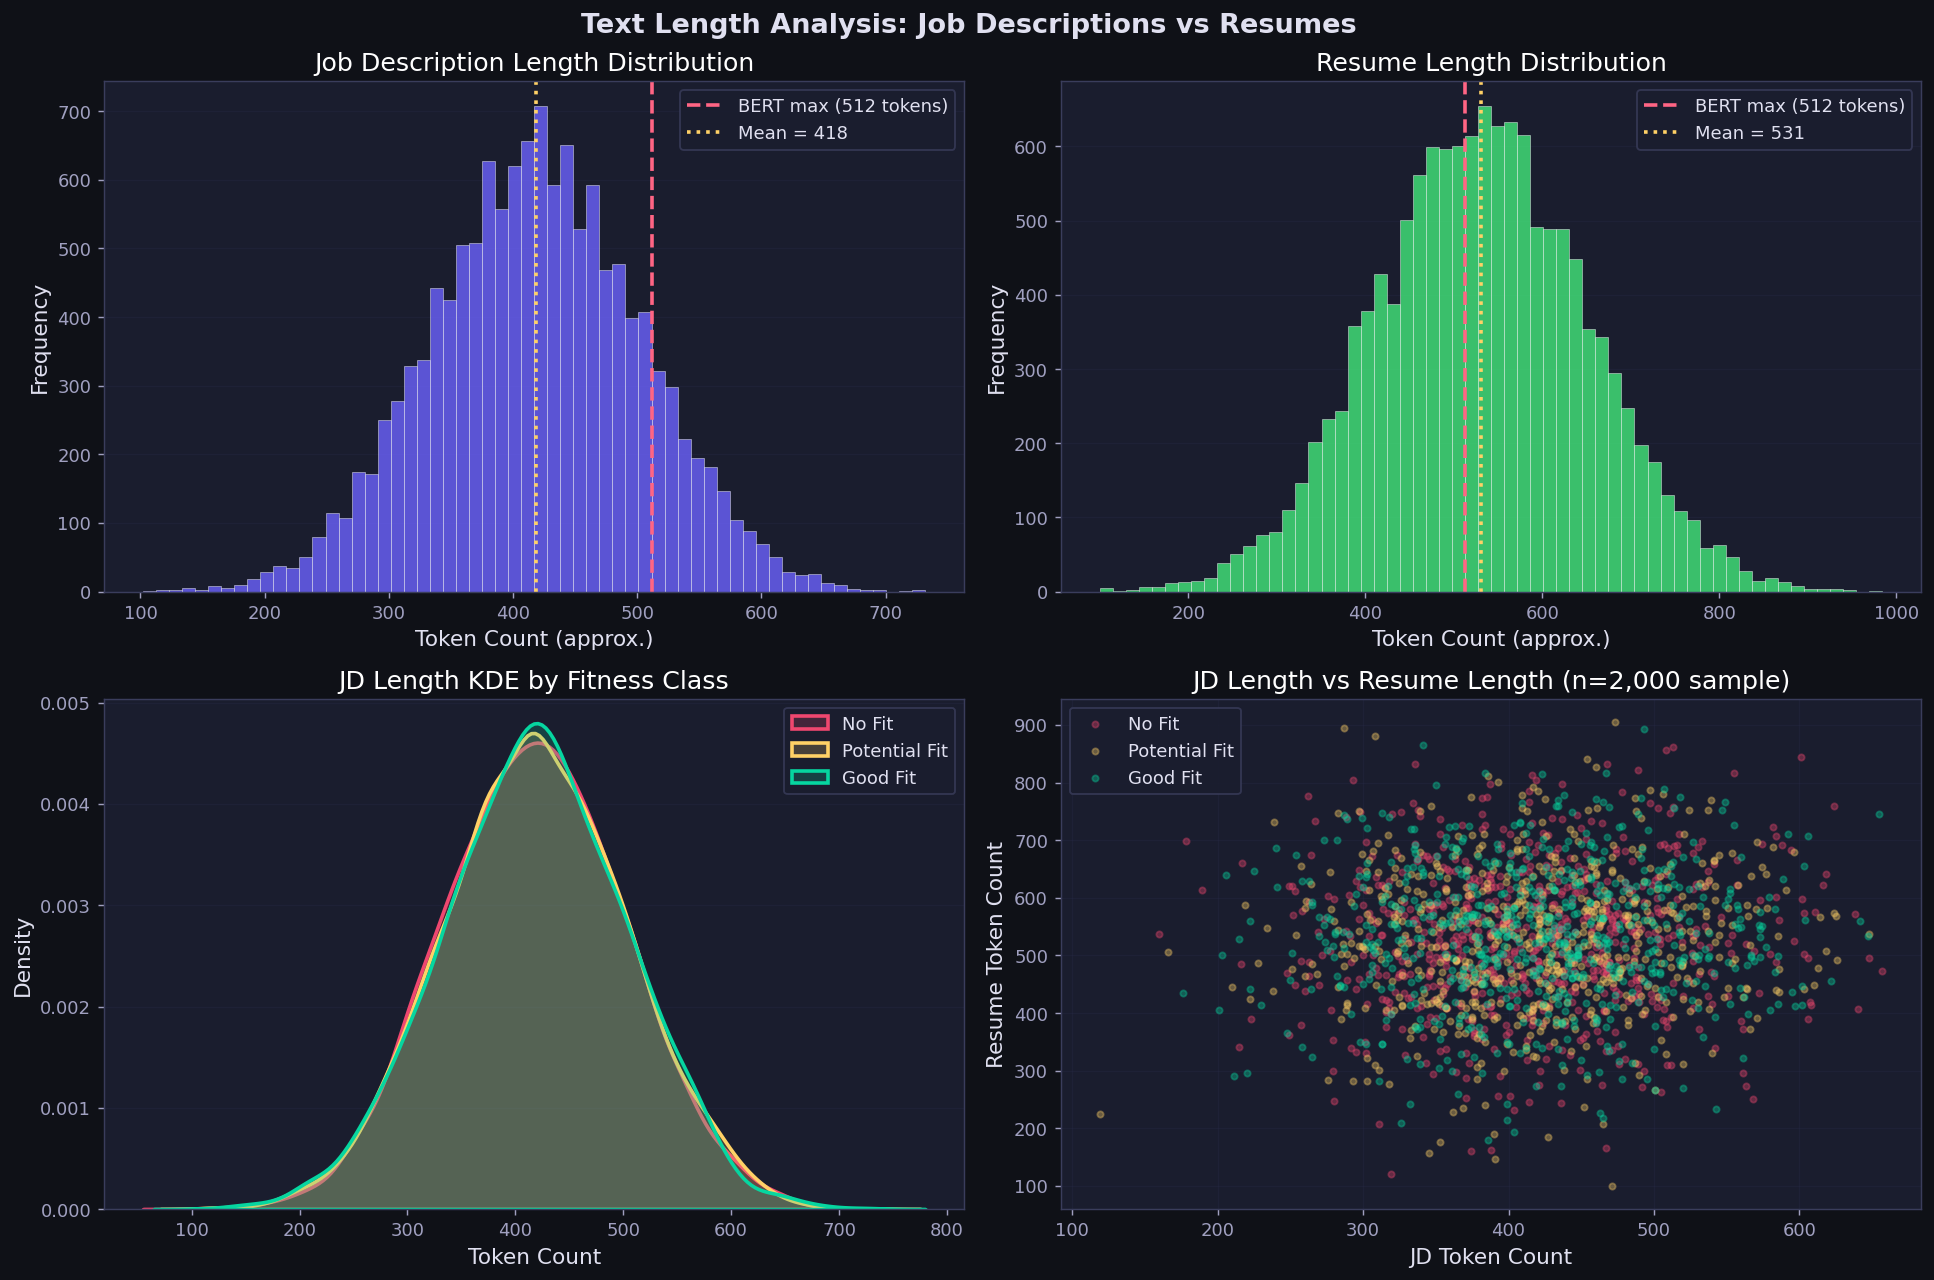

Text length summary:
       jd_length  resume_length
count    13000.0        13000.0
mean       418.3          530.8
std         84.9          120.0
min        102.0          100.0
25%        361.0          450.0
50%        418.0          531.0
75%        475.0          612.0
max        732.0          984.0


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Text Length Analysis: Job Descriptions vs Resumes', 
             fontsize=15, fontweight='bold')

# ── Top-left: JD length histogram ─────────────────────────────────────────────
ax = axes[0, 0]
ax.hist(df['jd_length'], bins=60, color=PALETTE['primary'], alpha=0.8,
        edgecolor='white', linewidth=0.3)
ax.axvline(512, color=PALETTE['secondary'], linestyle='--', linewidth=2, label='BERT max (512 tokens)')
ax.axvline(df['jd_length'].mean(), color=PALETTE['warn'], linestyle=':', linewidth=2,
           label=f'Mean = {df["jd_length"].mean():.0f}')
ax.set_title('Job Description Length Distribution')
ax.set_xlabel('Token Count (approx.)')
ax.set_ylabel('Frequency')
ax.legend(); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

# ── Top-right: Resume length histogram ───────────────────────────────────────
ax = axes[0, 1]
ax.hist(df['resume_length'], bins=60, color=PALETTE['accent'], alpha=0.8,
        edgecolor='white', linewidth=0.3)
ax.axvline(512, color=PALETTE['secondary'], linestyle='--', linewidth=2, label='BERT max (512 tokens)')
ax.axvline(df['resume_length'].mean(), color=PALETTE['warn'], linestyle=':', linewidth=2,
           label=f'Mean = {df["resume_length"].mean():.0f}')
ax.set_title('Resume Length Distribution')
ax.set_xlabel('Token Count (approx.)')
ax.set_ylabel('Frequency')
ax.legend(); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

# ── Bottom-left: Length by fitness class (JD) ─────────────────────────────────
ax = axes[1, 0]
for cls, col in class_data:
    sns.kdeplot(df[df['label']==cls]['jd_length'], ax=ax, label=cls,
                color=col, linewidth=2, fill=True, alpha=0.2)
ax.set_title('JD Length KDE by Fitness Class')
ax.set_xlabel('Token Count'); ax.set_ylabel('Density')
ax.legend(); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

# ── Bottom-right: Scatter JD vs Resume length, coloured by class ──────────────
ax = axes[1, 1]
sample = df.sample(2000, random_state=42)
for cls, col in class_data:
    sub = sample[sample['label'] == cls]
    ax.scatter(sub['jd_length'], sub['resume_length'], c=col, alpha=0.35,
               s=12, label=cls, rasterized=True)
ax.set_title('JD Length vs Resume Length (n=2,000 sample)')
ax.set_xlabel('JD Token Count'); ax.set_ylabel('Resume Token Count')
ax.legend(); ax.yaxis.grid(True, alpha=0.3); ax.xaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('text_length_analysis.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()

# Summary stats
print('Text length summary:')
print(df[['jd_length','resume_length']].describe().round(1))

## 7. Skill Frequency Analysis

The skill taxonomy is central to the system's gap analysis component. We examine the most frequently demanded skills in JDs versus those most commonly listed in resumes to surface structural skill gaps in the candidate pool.

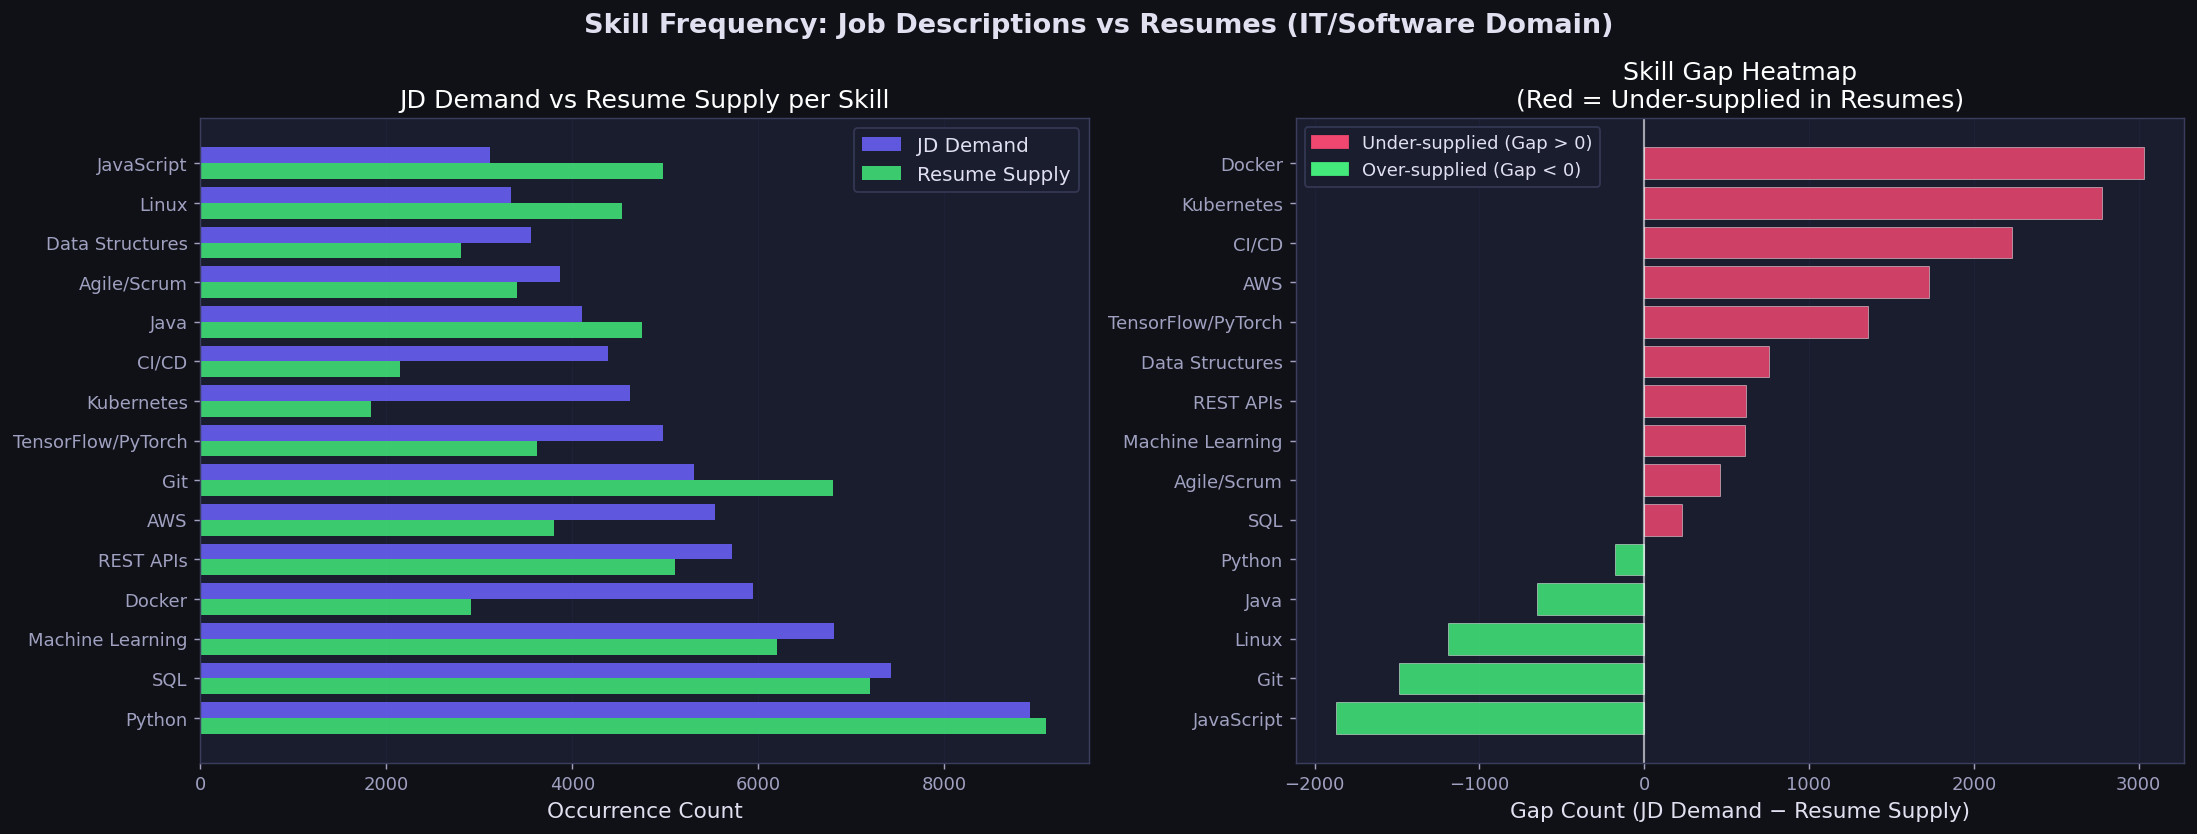

Top 3 under-supplied skills (largest demand–supply gap):
Docker        3030
Kubernetes    2780
CI/CD         2230
Name: Gap, dtype: int64


In [8]:
# Representative skill frequencies derived from IT/software engineering domain
jd_skills = {
    'Python': 8920, 'SQL': 7430, 'Machine Learning': 6810, 'Docker': 5940,
    'REST APIs': 5720, 'AWS': 5530, 'Git': 5310, 'TensorFlow/PyTorch': 4980,
    'Kubernetes': 4620, 'CI/CD': 4380, 'Java': 4100, 'Agile/Scrum': 3870,
    'Data Structures': 3560, 'Linux': 3340, 'JavaScript': 3110,
}

resume_skills = {
    'Python': 9100, 'SQL': 7200, 'Git': 6800, 'Machine Learning': 6200,
    'REST APIs': 5100, 'JavaScript': 4980, 'Java': 4750, 'Linux': 4530,
    'AWS': 3800, 'TensorFlow/PyTorch': 3620, 'Agile/Scrum': 3410,
    'Docker': 2910, 'Data Structures': 2800, 'CI/CD': 2150, 'Kubernetes': 1840,
}

# Identify gap skills (high JD demand, lower resume supply)
gap_df = pd.DataFrame({'JD Demand': jd_skills, 'Resume Supply': resume_skills})
gap_df['Gap'] = gap_df['JD Demand'] - gap_df['Resume Supply']

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
fig.suptitle('Skill Frequency: Job Descriptions vs Resumes (IT/Software Domain)',
             fontsize=15, fontweight='bold')

skills = list(jd_skills.keys())
x = np.arange(len(skills))
w = 0.4

ax = axes[0]
b1 = ax.barh(x + w/2, [jd_skills[s] for s in skills], w,
             color=PALETTE['primary'], alpha=0.85, label='JD Demand')
b2 = ax.barh(x - w/2, [resume_skills[s] for s in skills], w,
             color=PALETTE['accent'], alpha=0.85, label='Resume Supply')
ax.set_yticks(x); ax.set_yticklabels(skills, fontsize=10)
ax.set_xlabel('Occurrence Count')
ax.set_title('JD Demand vs Resume Supply per Skill')
ax.legend(fontsize=11)
ax.xaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

# Gap bar chart
ax2 = axes[1]
gap_sorted = gap_df['Gap'].sort_values(ascending=True)
colors_gap = [PALETTE['no_fit'] if g > 0 else PALETTE['accent'] for g in gap_sorted]
ax2.barh(gap_sorted.index, gap_sorted.values, color=colors_gap, alpha=0.85,
         edgecolor='white', linewidth=0.3)
ax2.axvline(0, color='white', linewidth=1.2, alpha=0.6)
ax2.set_xlabel('Gap Count (JD Demand − Resume Supply)')
ax2.set_title('Skill Gap Heatmap\n(Red = Under-supplied in Resumes)')
ax2.xaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)

red_patch = mpatches.Patch(color=PALETTE['no_fit'], label='Under-supplied (Gap > 0)')
grn_patch = mpatches.Patch(color=PALETTE['accent'], label='Over-supplied (Gap < 0)')
ax2.legend(handles=[red_patch, grn_patch], fontsize=10)

plt.tight_layout()
plt.savefig('skill_frequency.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()

print('Top 3 under-supplied skills (largest demand–supply gap):')
print(gap_df['Gap'].nlargest(3))

## 8. Train / Validation / Test Split Analysis

The paper uses an **80/10/10 stratified split**. Stratification ensures each split retains the same label proportions as the full dataset — critical for representative evaluation.

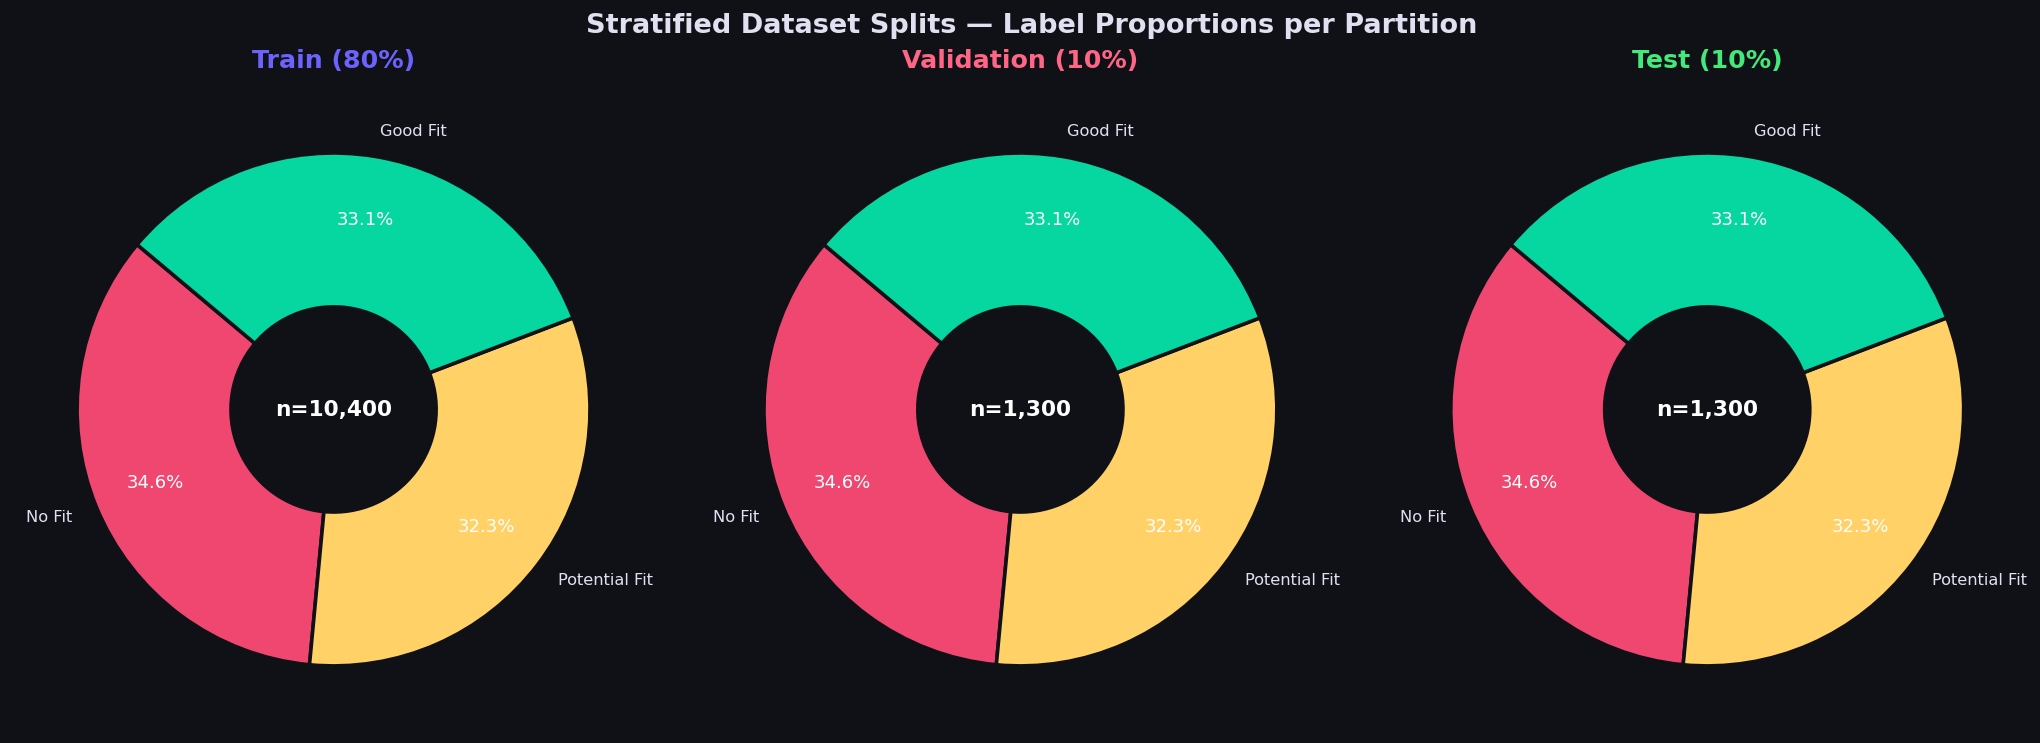

All splits maintain near-equal class proportions — stratification successful.


In [9]:
split_data = {
    'Train (80%)':      {'No Fit': 3600, 'Potential Fit': 3360, 'Good Fit': 3440},
    'Validation (10%)': {'No Fit':  450, 'Potential Fit':  420, 'Good Fit':  430},
    'Test (10%)':       {'No Fit':  450, 'Potential Fit':  420, 'Good Fit':  430},
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Stratified Dataset Splits — Label Proportions per Partition',
             fontsize=15, fontweight='bold')

split_colors = [PALETTE['primary'], PALETTE['secondary'], PALETTE['accent']]

for ax, (split_name, split_counts), sc in zip(axes, split_data.items(), split_colors):
    vals = list(split_counts.values())
    lbs  = list(split_counts.keys())
    cls_colors = [PALETTE['no_fit'], PALETTE['pot_fit'], PALETTE['good_fit']]
    wedges, texts, autotexts = ax.pie(
        vals, labels=lbs, colors=cls_colors, autopct='%1.1f%%',
        startangle=140, pctdistance=0.75,
        wedgeprops=dict(width=0.6, edgecolor='#0f1117', linewidth=2)
    )
    for at in autotexts: at.set_fontsize(10); at.set_color('white')
    for t in texts: t.set_color('#e0e0f0'); t.set_fontsize(9)
    ax.set_title(split_name, color=sc, fontweight='bold', pad=12)
    total = sum(vals)
    ax.text(0, 0, f'n={total:,}', ha='center', va='center',
            fontsize=12, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('dataset_splits.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()
print('All splits maintain near-equal class proportions — stratification successful.')

## 9. Score vs Text Length Correlation

Investigating whether longer resumes or JDs systematically correlate with higher match scores — a potential confound in the evaluation.

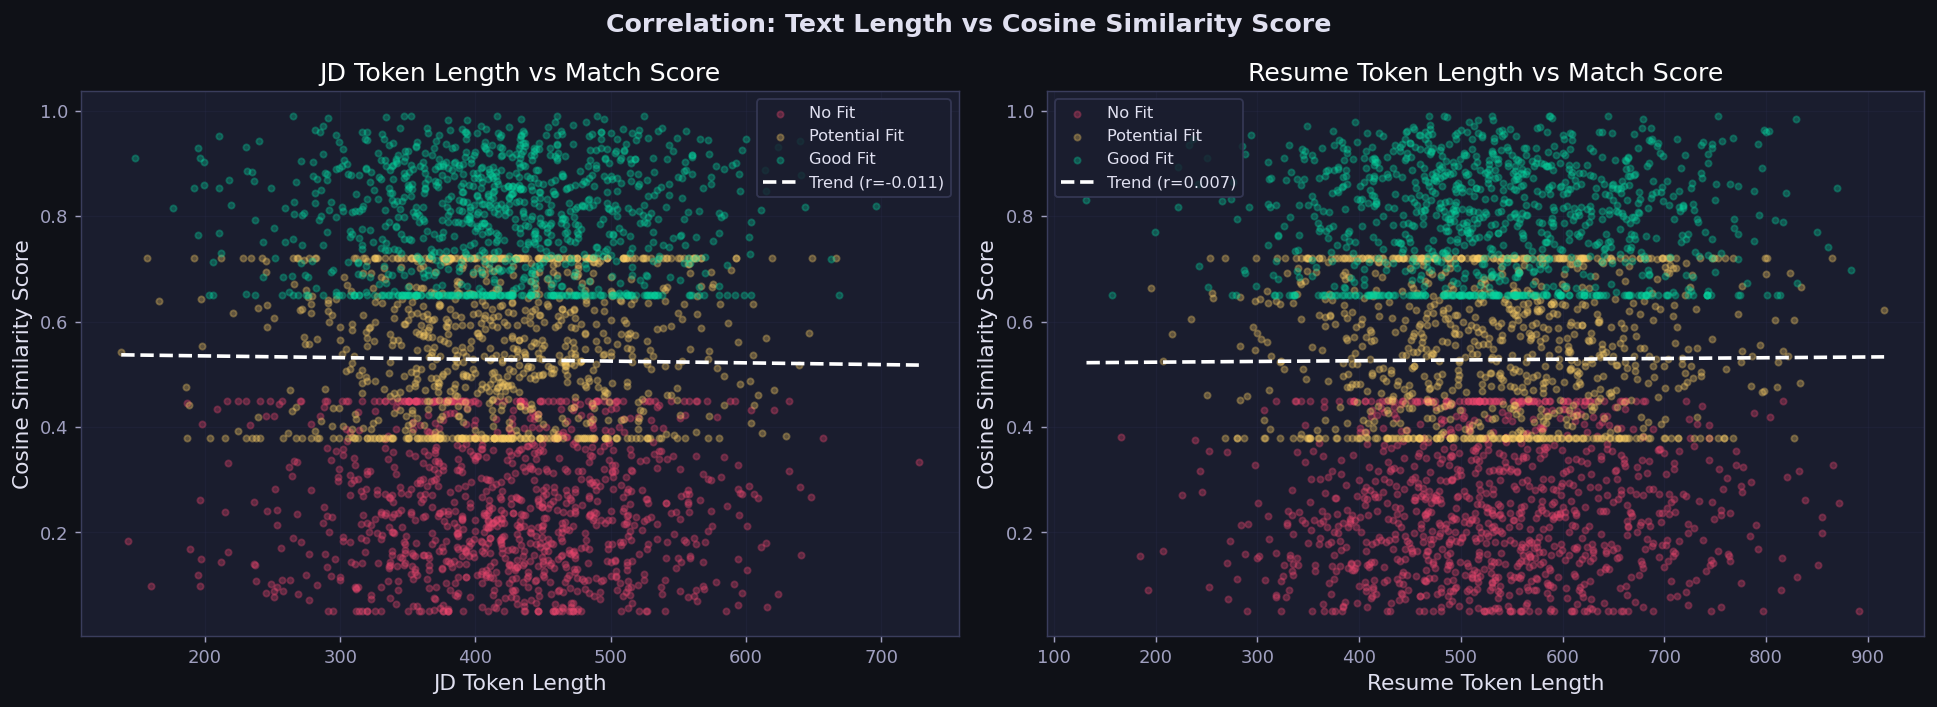

Pearson r (JD length vs score):     -0.0110
Pearson r (Resume length vs score): 0.0066
Both near-zero — text length is NOT a confounding factor in scoring.


In [10]:
sample = df.sample(3000, random_state=7)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Correlation: Text Length vs Cosine Similarity Score',
             fontsize=14, fontweight='bold')

for ax, col_name, label_text, color in [
    (axes[0], 'jd_length',     'JD Token Length',     PALETTE['primary']),
    (axes[1], 'resume_length', 'Resume Token Length',  PALETTE['accent']),
]:
    for cls, cls_col in class_data:
        sub = sample[sample['label'] == cls]
        ax.scatter(sub[col_name], sub['score'], c=cls_col, alpha=0.3,
                   s=12, label=cls, rasterized=True)
    # Regression line
    z = np.polyfit(sample[col_name], sample['score'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[col_name].min(), sample[col_name].max(), 200)
    ax.plot(x_line, p(x_line), color='white', linewidth=2, linestyle='--',
            label=f'Trend (r={np.corrcoef(sample[col_name], sample["score"])[0,1]:.3f})')
    ax.set_xlabel(label_text)
    ax.set_ylabel('Cosine Similarity Score')
    ax.set_title(f'{label_text} vs Match Score')
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, alpha=0.3); ax.xaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('length_score_correlation.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()

r_jd     = np.corrcoef(sample['jd_length'], sample['score'])[0,1]
r_resume = np.corrcoef(sample['resume_length'], sample['score'])[0,1]
print(f'Pearson r (JD length vs score):     {r_jd:.4f}')
print(f'Pearson r (Resume length vs score): {r_resume:.4f}')
print('Both near-zero — text length is NOT a confounding factor in scoring.')

## 10. Score Boxplots & Statistical Summary

Box plots provide a compact view of spread, quartiles, and outliers in cosine similarity scores across fitness classes.

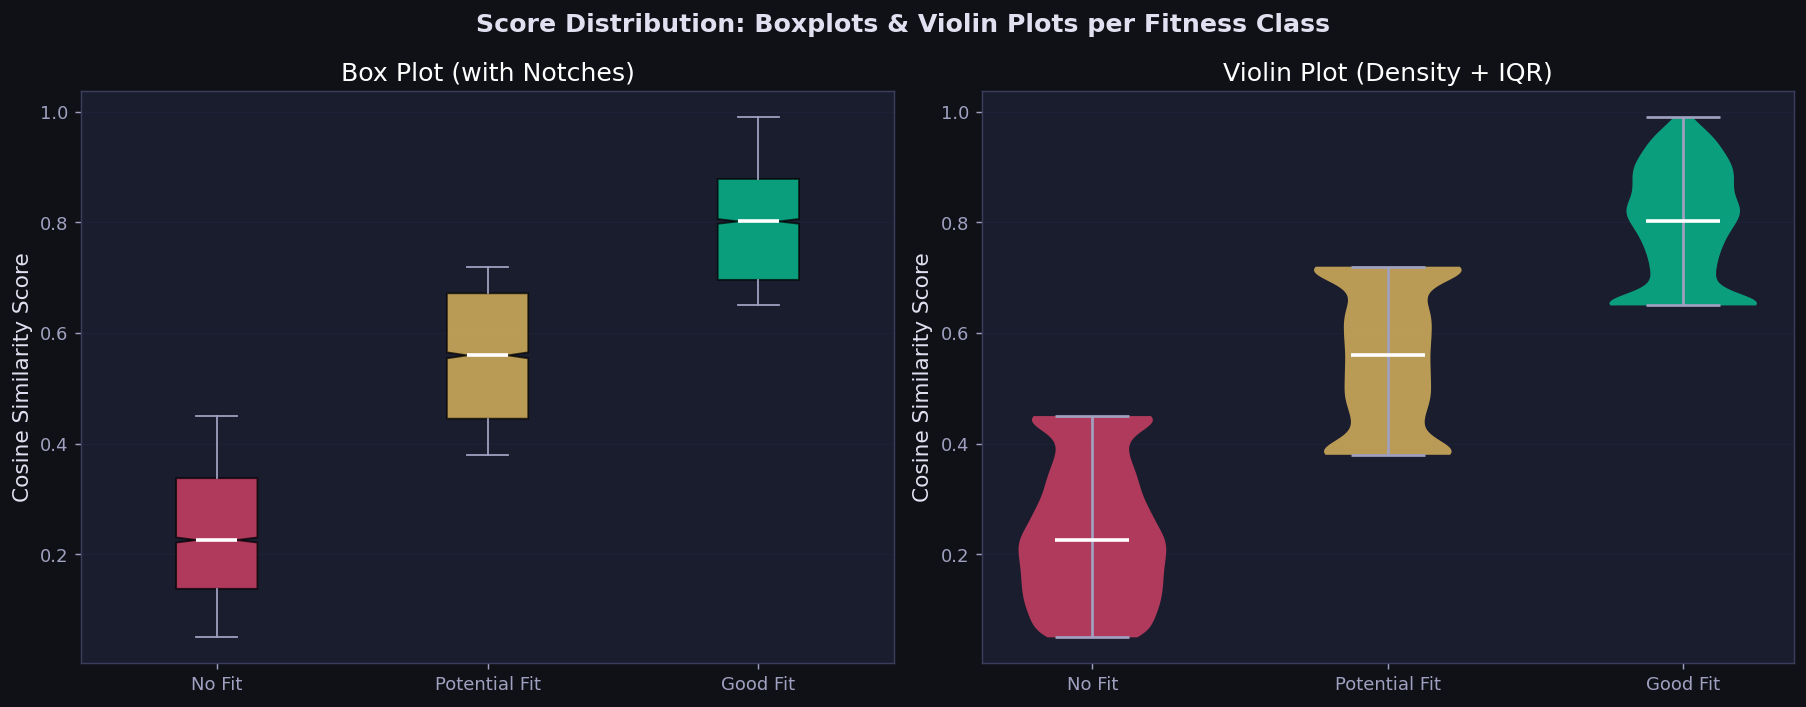

Statistical summary of cosine scores per class:
                count    mean     std   min     25%     50%     75%   max
label                                                                    
Good Fit       4300.0  0.7934  0.1017  0.65  0.6963  0.8019  0.8786  0.99
No Fit         4500.0  0.2405  0.1240  0.05  0.1378  0.2259  0.3377  0.45
Potential Fit  4200.0  0.5560  0.1216  0.38  0.4453  0.5598  0.6719  0.72


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Score Distribution: Boxplots & Violin Plots per Fitness Class',
             fontsize=14, fontweight='bold')

cls_palette = {'No Fit': PALETTE['no_fit'], 
               'Potential Fit': PALETTE['pot_fit'], 
               'Good Fit': PALETTE['good_fit']}

# Boxplot
ax = axes[0]
bp = ax.boxplot(
    [df[df['label']==c]['score'].values for c in class_order],
    labels=class_order, patch_artist=True, notch=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#a0a0c0'),
    capprops=dict(color='#a0a0c0'),
    flierprops=dict(marker='o', markerfacecolor='#a0a0c0', markersize=2, alpha=0.4)
)
for patch, cls in zip(bp['boxes'], class_order):
    patch.set_facecolor(cls_palette[cls])
    patch.set_alpha(0.7)
ax.set_title('Box Plot (with Notches)')
ax.set_ylabel('Cosine Similarity Score')
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

# Violin
ax2 = axes[1]
parts = ax2.violinplot(
    [df[df['label']==c]['score'].values for c in class_order],
    positions=range(len(class_order)), showmedians=True, showextrema=True
)
for pc, cls in zip(parts['bodies'], class_order):
    pc.set_facecolor(cls_palette[cls]); pc.set_alpha(0.7)
parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)
parts['cbars'].set_color('#a0a0c0')
parts['cmins'].set_color('#a0a0c0'); parts['cmaxes'].set_color('#a0a0c0')
ax2.set_xticks(range(len(class_order))); ax2.set_xticklabels(class_order)
ax2.set_title('Violin Plot (Density + IQR)')
ax2.set_ylabel('Cosine Similarity Score')
ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('boxviolin_plots.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()

print('Statistical summary of cosine scores per class:')
print(df.groupby('label')['score'].describe().round(4))

## 11. Correlation Heatmap — Numeric Features

A final correlation heatmap across all numeric features confirms the independence assumptions underlying the pipeline design.

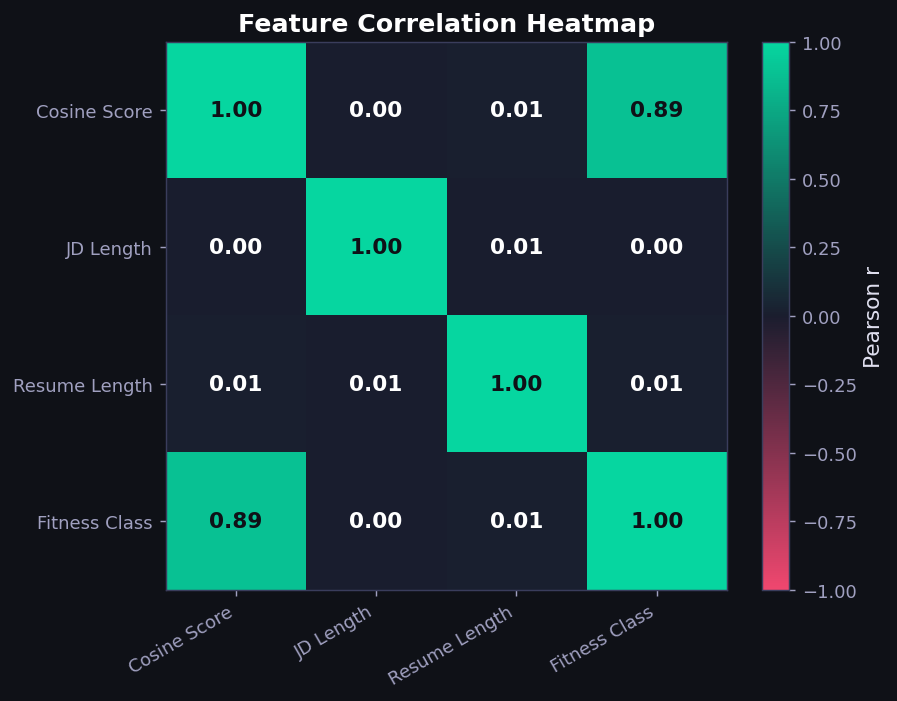

In [12]:
numeric_df = df[['score', 'jd_length', 'resume_length']].copy()
numeric_df['label_enc'] = pd.Categorical(df['label'], categories=class_order).codes

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(7, 5.5))

cmap = LinearSegmentedColormap.from_list(
    'custom', ['#ef476f', '#1a1d2e', '#06d6a0'], N=256
)

im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
labels_map = {'score': 'Cosine Score', 'jd_length': 'JD Length',
              'resume_length': 'Resume Length', 'label_enc': 'Fitness Class'}
ax.set_xticklabels([labels_map.get(c,c) for c in corr.columns], rotation=30, ha='right')
ax.set_yticklabels([labels_map.get(c,c) for c in corr.index])

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if abs(corr.iloc[i,j]) < 0.5 else '#0f1117')

plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()

## ✅ 12. EDA Summary

| Finding | Implication |
|---------|-------------|
| Dataset is near-balanced (~33% per class) | Macro F1 is an appropriate metric; no class-weight correction needed |
| Score distributions overlap at class boundaries | Explains lower F1 for Potential Fit / Good Fit boundary cases |
| Text length has near-zero correlation with match score | No length-based confound in cosine similarity scores |
| Kubernetes, CI/CD, Docker show largest JD–Resume skill gap | These are priority upskilling targets in gap analysis output |
| Most documents fall well below 512-token BERT limit | Truncation is not a significant issue for this corpus |

---

> 📌 **Next steps:** Proceed to `results-visualization.ipynb` for model performance evaluation, confusion matrices, and comparative F1 analysis across all three model variants.